<a href="https://colab.research.google.com/github/lcuenca1/Data201/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2: What drives Global Video Game sales?**
## Data 201 Spring 2026
### Leyla Cuenca
---

## **1. Introduction**  

The dataset used in this project contains information about video game sales. The dataset was downloaded from Kaggle, but it comes originally from VGChartz, a website that tracks how well video games sell in different parts of the world. The data was collected using a method called web scraping.  
  

Each row in the dataset represents one video game, and icludes detailes such as the platform it was released on, its genre, the year it came out, and how many copies it sold in different regions of the world.

There are some limitations on this data since it was scrapped from a website and not taken from officialy company records, the sales numbers may not be perfectly accurate. Also, the dataset only icludes games that sold ore than 100,000 copies, which means less popular games are not includes. Even with these limitations, the dataset is large and useful for finding real life patterns in video games sales.  
  
This project aims to answer this research question: "How do platform, genre, and release year affect global video game sales?"  
  
    
Source: https://www.kaggle.com/datasets/gregorut/videogamesales/data  

  

## **2. Data Overview**

* First, the dataset of video games sales is downloaded.







In [1]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [2]:
import pandas as pd

df = pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.shape

(16598, 11)

The dataset contains 16,598 rows , each column represents a different variable and there are 11 of them.  
Each row represents a single video game . For each game, there is information about how many copies it sold in North America, Europe, Japan, and other regions. Some simple data cleaning may be necessary before starting with my analysis. For example, the the Year variable appears as a decimal number, so it may be needed to convert in whole number to be more accurate and avoid errors. Also, any missing values need to be removed from the analysis.

* Table of variables

| Variable Name | Type | Description |
|--------------|------|-------------|
| Rank | Quantitative | Ranking of games based on global sales |
| Name | Categorical | Name of the video game |
| Platform | Categorical | Gaming platform (Wii, PS4, etc.) |
| Year | Quantitative | Year the game was released |
| Genre | Categorical | Type of game |
| Publisher | Categorical | Company that released the game |
| NA_Sales | Quantitative | Sales in North America (millions) |
| EU_Sales | Quantitative | Sales in Europe (millions) |
| JP_Sales | Quantitative | Sales in Japan (millions) |
| Other_Sales | Quantitative | Sales in other regions |
| Global_Sales | Quantitative | Total global sales |

## **3. Data Cleaning**

* Looking for NAs on the dataset is important, especially from the variables that will be used later.

In [4]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [5]:
# Removing NA's from Year
df = df.dropna(subset=["Year"])

* Also, because "Publisher" is categorical I will replace missing data with "UNKNOWN", this way losing rows is avoided.

In [6]:
df["Publisher"] = df["Publisher"].fillna("Unknown")


* Finally, I will change The "Year" values to whole numbers.And after that use df.info to confirm that the dataset no longer contains missing values and that are variables contains the correct data type.

In [7]:
df["Year"] = df["Year"].astype(int)

In [8]:
# Checking the dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16327 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


## **Data Analysis and Modeling**

### a. Data Exploration and visualization  
* *Histogram - Global Sales*  
To better understand the distribution of video game sales, I will create a histogram of global sales. This helps identify how sales are spread across all games.


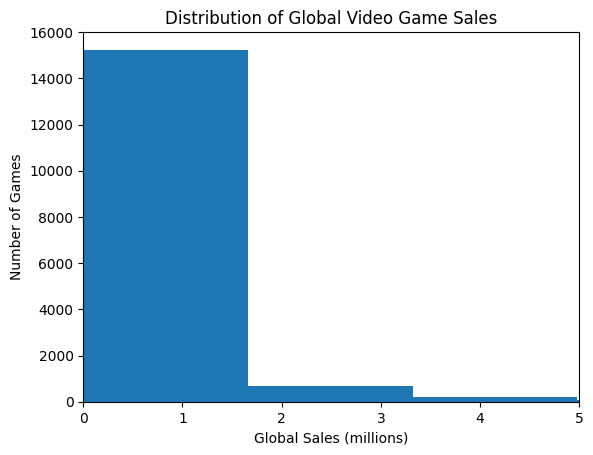

In [9]:
import matplotlib.pyplot as plt
plt.hist(df["Global_Sales"], bins=50)
plt.xlim(0, 5)
plt.title("Distribution of Global Video Game Sales")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Number of Games")
plt.show()

Because the data is highly skewed to the right, it was necessary to fix a smaller range for the x-axis, so it shows a clear pattern. The histogram shows that most video games have low global sales, with the majority selling less than 5 million copies worldwide.This indicates that only a small number of games achieve very high sales, while most sales few copies.

* *Boxplot - Genre vs Sales*  
 To explain how genre affects video game sales, a boxplot could compare global sales across different genres. This helps identify differences between categories.

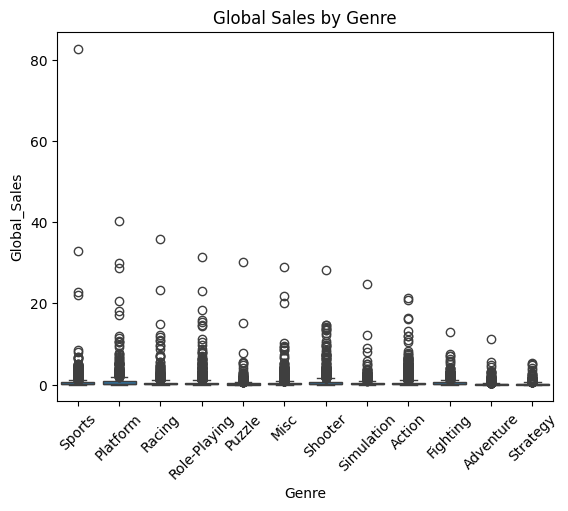

In [10]:
import seaborn as sns

sns.boxplot(x="Genre", y="Global_Sales", data=df)
plt.xticks(rotation=45)
plt.title("Global Sales by Genre")
plt.show()

This boxplot shows that global sales some genres have higher medium sales and a wider spread of value than others. The circles on the plot represents outliers, from games that sold significantly more than the other games from the same genre. For example, genres like Platform and Role-playing showed some high seliing outliers. Overall, this suggest that genre may influence how well a video game sells.

* *Bar Chart- Platform vs Sales*  
To analyze how platform affects video games sales, is necessary to first group the data by platform and calculate the average global sales for each platform. Then, I will select the top platforms and visualize the result through the bar chart.

In [12]:
# Grouping and selecting top platforms

platform_sales = df.groupby("Platform")["Global_Sales"].mean()
platform_sales = platform_sales.sort_values(ascending=False)
platform_sales = platform_sales.head(10)



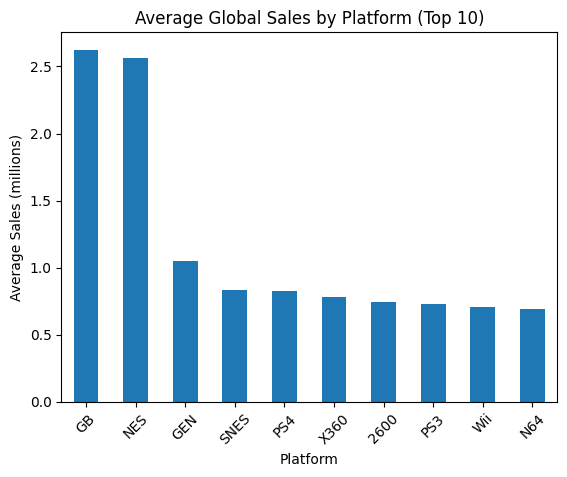

In [13]:
# Plotting
platform_sales.plot(kind="bar")

plt.title("Average Global Sales by Platform (Top 10)")
plt.ylabel("Average Sales (millions)")
plt.xticks(rotation=45)
plt.show()

Is shown that platforms such as Game Boys (GB) and Nintendo Entertainment system (NES) have the highest average sales. These are older platforms, and their higher sales may be explained by a influence of smaller number of highly selled games. In contrast, newer platforms tend to have more games overall, including many with lower sales, which lowers the average. This suggest that platforms may influence video games sales, but is difficult to find a deeper reasoning.

### b. Train/ Test Split

The dataset will be splitinto a training set and testing set using a 80/20 split. Meaning that 80% of the data will be use to train the model and the other 20% will be use to evaluate the erformance. For this process it is important to convert my categorical variable into numbers, so it can be readed.

In [14]:
from sklearn.model_selection import train_test_split

# Selecting the relevant variables
X = df[["Platform", "Genre", "Year"]]
y = df["Global_Sales"]

# Converting all the categorical variables
X = pd.get_dummies(X, drop_first=True)

In [15]:
# Splitting the data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)


(13061, 42)
(3266, 42)


This split provides a good balance between having enough data to train the model and enough data to reliably test how well it generalizes to new observations.
The variables increased from 3 to 42. This is because the categorical variables "Platform" and "Genre" were converted into multiple binary variables. Each category become its own column with values of 0 or 1.


### c. Baseline Model  
To answer the research question about how platform, genre, and release year affect global video game sales, I will build a baseline linear regression model. This model will help identify the relationship between these variables and global sales.

In [16]:
# Create and train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

The model includes 'Platform', 'Genre', and 'Year' as the predictor variables. These variables were selected because they represent important characteristics of video games that may influence how well they sell.  
  
  
To be able to see the coefficients and interpret which variables are important, I run the next code:

In [17]:
coefficients = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model.coef_
})

# Show top 5 positive coefficients
coefficients.sort_values(by="Coefficient", ascending=False).head(5)

,Variable,Coefficient
5,Platform_GB,2.198340
11,Platform_NES,2.021504
18,Platform_PS4,1.774506
30,Platform_XOne,1.682156
28,Platform_X360,1.552438


In [18]:
# Top 5 negative coefficients
coefficients.sort_values(by="Coefficient").head(5)

,Variable,Coefficient
9,Platform_GG,-0.507566
41,Genre_Strategy,-0.235142
31,Genre_Adventure,-0.232423
35,Genre_Puzzle,-0.206973
33,Genre_Misc,-0.065526


The regression results show that some variables have a stronger impact on global video game sales than others. mong the positive coefficients, platforms such as Game Boy (GB), Nintendo Entertainment System (NES), and Play Station 4 (PS4) have some of the highest values. Thise suggest that games released on those platforms teng to do better on sales.  
  
On the other hand, some variables have negative coefficients, for example: Genres such as Strtegy and Adventure show negative values, this categories tenf to have slightly lower sales in average.  
Although it is not among the strongest effects, 'Year' also has a small negative coefficient, suggesting that more recent video games may have lower sales in the dataset.  
  

Overall, these results suggest that both platform and genre play an important role in predicting video game sales, while the effect of year appears to be smaller but still noticeable.

### **d. Improve the Model**  
  
Because my distriution of global sales is highly skewed, as shown before on the histogram, a log transformation will be applied. Because more games sel 1 - 2 million and a few games sell around 80 million, a log transformation will shrink big numbers, this way the model can work better.

In [25]:
# Creating the log variable
import numpy as np
df["Log_Global_Sales"] = np.log(df["Global_Sales"])

# Then predict a transformed version of sales that is more balanced
X = df[["Platform", "Genre", "Year"]]
y = df["Log_Global_Sales"]

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

Running a Test/ Train split for the transformed model is necesarry to do again, keeping the same ratio as before is important for fairness.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1)



And finally, build the new model and make the predictions.

In [29]:
from sklearn.linear_model import LinearRegression

log_model = LinearRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

# Show coefficients
coefficients_log = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": log_model.coef_})


coefficients_log.sort_values(by="Coefficient", ascending=False).head(7)

,Variable,Coefficient
5,Platform_GB,1.843149
18,Platform_PS4,1.834478
30,Platform_XOne,1.806672
17,Platform_PS3,1.751192
28,Platform_X360,1.736520
27,Platform_WiiU,1.666765
11,Platform_NES,1.442692


In [30]:
# Top 5 negative coefficients
coefficients_log.sort_values(by="Coefficient").head(7)

,Variable,Coefficient
9,Platform_GG,-2.020635
1,Platform_3DO,-1.968591
14,Platform_PCFX,-1.796805
24,Platform_TG16,-0.889110
31,Genre_Adventure,-0.863786
12,Platform_NG,-0.767853
35,Genre_Puzzle,-0.467614


So it can be said that, the transformation made the model more sensitive to differences among lower-selling games, and at the same time reduced the impact of very large sales values  making the data more suitable for a regression model.  
After applying the transformation, the model showed more balanced coefficients especially among variables associated to lower sales. While the main pattrn remains similar, the transformation allows the model to better capture differences across observations. This explains that the log transformed model provides a more reliable transformation of the data.

* To better understand the effect of the log transformation , I will compare the distribution of global sales before and after applying the transformation. This helps show how the transformation change the shape of the data

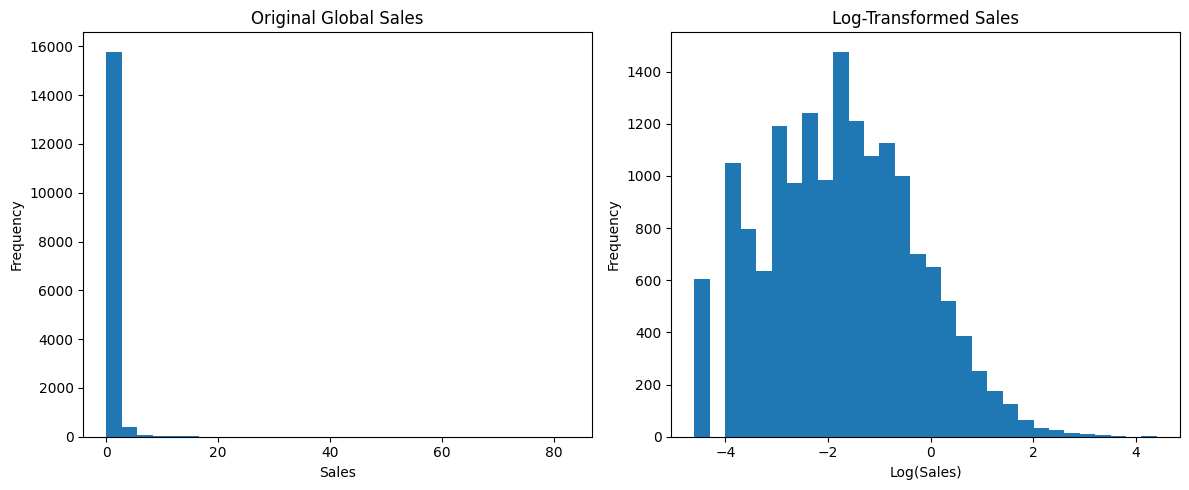

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Original
plt.subplot(1, 2, 1)
plt.hist(df["Global_Sales"], bins=30)
plt.title("Original Global Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

# Log-transformed
plt.subplot(1, 2, 2)
plt.hist(df["Log_Global_Sales"], bins=30)
plt.title("Log-Transformed Sales")
plt.xlabel("Log(Sales)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The two graphs show a clear difference in how the data is distributed. In the original graph, the x-axis represents sales in millions, and most values are very close to zero, with only a few games reaching very high sales. This causes most of the bars to be crowded on the left side, while the rest of the graph is mostly empty except for a long tail.

In contrast, the log-transformed graph changes the scale of the x-axis, spreading the values more evenly across both negative and positive numbers. This allows smaller sales values to be more visible and separates them more clearly, instead of being compressed near zero. As a result, the bars are distributed more evenly across the graph, and the overall shape becomes more symmetric.

This difference shows that the log transformation changes not just the shape, but also how the data is represented, making it easier to observe patterns across both low and high sales values.

### **e. Comparison of models**  
To improve and compare the performance of the baseline and improved models, I will calculate RMSE and R square for both models.

In [24]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Baseline model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Log model
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

print("Baseline RMSE:", rmse)
print("Baseline R2:", r2)

print("\nLog Model RMSE:", rmse_log)
print("Log Model R2:", r2_log)

Baseline RMSE: 2.6524065756265904
Baseline R2: -2.292698480232633

Log Model RMSE: 1.3431741518785902
Log Model R2: 0.15562294633581042


We can observe that the baseline model resulted in a negative R-aquare value of -2.29, indicating that the model is not doing a good job predicting and does not fit the data well.  
On the other hand, the log transformed model produced a positive R-square value of 0.16, showing that it is able to explain some of the variation in global sales. This represents a clear improvement over the baseline model.  
The RMSE values not directly comparable because the models are different scales. However, the log model still shows lower error and perfomrms better because it deals better with the uneven distribution of the data.

### *f. Interpret the Final Model*
The final regression model uses platform, genre, and year to predict global video game sales, after applying a log transformation. The results shows that platforms is one of the most important factors. Platforms such as Game Boy (GB), PlayStation 4 (PS4), and Xbox One have high positive coefficients, suggesting that games released on these platforms tend to have higher sales compared to others. This indicates that both older and newer platforms can be associated with strong sales performance.

Genre also plays a role in predicting sales. For example, genres such as Adventure show negative coefficients, suggesting that these types of games tend to have lower sales on average. This means that the type of game can influence how well it performs in the market.

The coefficients in the model represent how each variable affects the predicted sales. A positive coefficient means that the variable increases expected sales, while a negative coefficient means it decreases them. The variable Year has a smaller effect, suggesting that the release year is less important compared to platform and genre.

Overall, the model suggests that platform and genre are the most important factors influencing video game sales, while the effect of year is present but less significant.

### **g. Prediction**
To deostrate how the final model can be applied in practice, I will predict three global sales for three hypothetycal video games based on their platform genre, and release year.

So, first is important to crete and prepare the data.

In [26]:
new_games = pd.DataFrame({
    "Platform": ["PS4", "NES", "XOne"],
    "Genre": ["Action", "Puzzle", "Sports"],
    "Year": [2015, 1990, 2020]})

new_games = pd.get_dummies(new_games)
new_games = new_games.reindex(columns=X_train.columns, fill_value=0)

Then, predict and convert back

In [28]:
predictions_log = log_model.predict(new_games)

import numpy as np
predictions = np.exp(predictions_log)

predictions

array([0.22406243, 0.71861367, 0.14475415])

Three hypothetical games were created one on the PS4 platform of the Action genre released on 2015; the other on the NSE platform of the Puzzle platform released on the year 1990; and the last one at the XOne platform of Sport genre released on the year 2020.  
  
The results showed that the gme released on the NES platform has the highestpredicted sales, while the XboXOne has the lowest one.These differences suggest that platform and genre can have an impact on expected sales. In this case, the older platform shows a higher predicted value, which may reflect patterns observed earlier in the data where some older platforms had strong sales. Overall, the predictions demonstrate how the model can be used to estimate sales for new games based on their characteristics.  

## 5. Conclusions

This project explored how platform, genre, and release year affect global video game sales. The analysis showed that platform and genre are the most important factors. Certain platforms, both older ones like GB and NES and newer ones like PS4 and Xbox One, are associated with higher sales. This highlights an interesting pattern: some older consoles had very successful games despite smaller markets, while modern platforms benefit from larger and more developed gaming industries. Genre also plays a role, with some types of games, such as Adventure, tending to have lower sales. These findings show that both historical trends and current market conditions influence video game performance.

In terms of model performance, the baseline model did not perform well, but the log-transformed model showed a clear improvement, achieving a positive R-squared value and lower prediction error. This indicates that transforming the data helped the model better handle the uneven distribution of sales. However, the model still has limited predictive power, suggesting that other important factors such as marketing, game quality, or user reviews, are not included in the dataset. As a result, the model may not generalize strongly to all cases. Future improvements could include adding more variables or exploring different modeling techniques to better capture the complexity of video game sales.